# 06 — Per-pixel SEDs and the trusted power-law fit (stage 3)

**TRIS + ARCADE 2 only:** the four absolutely calibrated, trusted points. (Every other survey
in `res/` is added in `notebooks/07`–`08`.) At **every pixel of the TRIS
stripe** (where TRIS data exist, 1272 nside 16 pixels), this notebook does four things:

1. builds the SED: TRIS 600 and 820 everywhere, plus ARCADE 2 3.15 and 3.41 where ARCADE 2
   has data (and Haslam, not fitted);
2. fits $T(\nu) = A\,(\nu/\nu_0)^\beta$ to those points: **four** where both ARCADE 2
   bands are present, **three** where only one is, **two** (TRIS only) elsewhere;
3. evaluates the fit at 408 MHz and compares it with Haslam;
4. records the χ² where ARCADE 2 is present (n − 2 = 1 or 2 degrees of freedom). A two-point
   fit passes exactly through both points: 0 degrees of freedom, so it has no χ².

It stops there. **No calibration correction is derived or applied (stage 4).**

### Conventions, each checked against its source

| point | map | ν used [MHz] | units on disk | error bar |
|---|---|---|---|---|
| 408 | Haslam, stage 2 product (TRIS beam, nside 16), **not fitted** | 408 | K, RJ, CMB included (config `haslam.remove_cmb_monopole`) | — |
| 600 | TRIS stage 1, nside 16 | 600.5 (effective) | K, RJ, CMB included | posterior σ |
| 820 | TRIS stage 1, nside 16 | 817.8 (effective) | K, RJ, CMB included | posterior σ |
| 3150 | ARCADE 2, stage 2 product | 3150 | **K thermodynamic, CMB included** | white noise ⊕ calibration |
| 3410 | ARCADE 2, beam-matched | 3410 | same | same |

* **ARCADE 2 units.** From the LAMBDA product description: *"units K thermodynamic
  temperature … no other Galactic or cosmological source has been removed"*. Only the
  dipole is removed.
* **The 3.15 GHz channel frequency.** It is labelled 3.20 GHz in Fixsen et al. 2011
  (Table 4), and 3.15 GHz in the FITS header and in Singal et al. 2011 (Table 2). The
  header value is used here.
* **The fit quantity.** Everything is converted to **antenna temperature with the CMB
  removed**: the Galactic plus extragalactic excess, the form Fixsen et al. 2011 fit
  (their eq. 7, $T_A = T\,x/(e^x - 1)$, $x = h\nu/kT$). For ARCADE 2 that is
  $T_A(T_\mathrm{map}) - T_A(T_0)$ with $T_0 = 2.72548$ K. The difference between the
  two conventions is 0.074 K at 3.15 GHz, comparable to the signal itself.
* **ARCADE 2 error.** White noise comes from Singal et al. 2011 Table 2 (map noise
  11.8 and 10.1 mK√s, `N_OBS` × 0.5 s), propagated through the smoothing. It is added in quadrature to the calibration terms of Fixsen et al. 2011
  Table 3 (thermometer and radiometer calibration, instrument emission, atmosphere), which
  come to **7.5 mK** (3.15 GHz) and **6.0 mK** (3.41 GHz).

**One modelling choice, made explicitly: TRIS = `sky_k` + fitted zero level ẑ.** The
stage 1 fit splits the ring's brightness between the sky pixels and a zero-level offset
ẑ. The ring cannot tell those two apart (monopole degeneracy ≈ 1), and notebook 03 showed
that ẑ ≈ 1.74 K (600 MHz) reproduces GSM2008's own deficit. That makes ẑ sky brightness,
not an instrument offset: the archive's published zero-level systematic is 0.066 K. So
the absolute sky temperature per pixel is $\hat{x}_p + \hat{z}$. Its variance is taken
from the full posterior covariance, $\Sigma_{pp} + \Sigma_{zz} + 2\Sigma_{pz}$. In
practice this matches the quadrature sum to 0.3%: ẑ is degenerate with the *sum* of the
pixels, not with any single one. Section 6 shows what happens without ẑ.

In [ ]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import frames
from moonrunes.stage1_tris_maps import load_stage1, import_limtod_tris
from moonrunes.stage2_beam_matching import (smooth_to_target, extra_fwhm_deg, observed_mask,
                                            load_stage2)

config = load_config(REPO / "configs" / "run_config.yaml")
tris = import_limtod_tris(config)
NSIDE = int(config.require("tris.nside"))                                   # 16
TARGET_FWHM_DEG = float(config.require("beam_matching.target_fwhm_deg"))     # 23.366
HASLAM_NATIVE_FWHM_DEG = float(config.require("beam_matching.haslam_native_fwhm_deg"))
ARCADE2_NATIVE_FWHM_DEG = float(config.require("beam_matching.arcade2_native_fwhm_deg"))  # 11.6
WEIGHT_FLOOR = float(config.require("beam_matching.weight_floor"))           # 0.5
NU0_MHZ = 408.0                  # so A is the fitted excess at 408 MHz directly
T_CMB = 2.72548
BETA_FLAG = (-3.5, -2.0)
BENCH_SCALE = float(config.require("validate.gain_scale_expected"))     # 0.03
BENCH_ZERO_K = float(config.require("validate.zero_level_expected_k"))  # 0.91

_H, _K = 6.62607015e-34, 1.380649e-23
def antenna_temperature(t_thermo_k, nu_mhz):
    # Fixsen et al. 2011 eq. 7: T_A = T x / (e^x - 1), x = h nu / k T
    x = _H * nu_mhz * 1e6 / (_K * np.asarray(t_thermo_k, dtype=float))
    return t_thermo_k * x / np.expm1(x)

# ARCADE 2: (file key, frequency, map white noise [K sqrt(s)], calibration systematic [K])
ARCADE = {3150.0: ("paths.arcade2_map_3150", 11.8e-3, 7.5e-3),
          3410.0: ("paths.arcade2_map_3410", 10.1e-3, 6.0e-3)}

---
## 1. The value arrays: stage 1 and stage 2 products

Everything needed is already on the nside 16 TRIS grid, in equatorial:

* **TRIS 600 / 820:** stage 1's maps (`outputs/stage1/`);
* **Haslam and ARCADE 2:** stage 2's product (`outputs/stage2/`), matched to the TRIS beam
  with the final mask (observed **and** smoothed weight ≥ 0.5). ARCADE 2 is native nside 16,
  so no regridding is involved.

ARCADE 2's white noise is propagated here through the same smoothing, because stage 2
stores values, not noise.

In [ ]:
products = load_stage1(config)                    # outputs/stage1/
stage2 = load_stage2(config)                      # outputs/stage2/
assert products.nside == stage2.nside == NSIDE
print(f"stage 1: {products.maps_path.relative_to(REPO)}, nside {products.nside}")
print(f"stage 2: {stage2.maps_path.relative_to(REPO)}, nside {stage2.nside}, maps {stage2.names}")

HASLAM_MAP = stage2.map("haslam_408")
assert np.all(stage2.observed("haslam_408")), "Haslam should be full sky"

# ARCADE 2: values from stage 2; white noise propagated through the same smoothing.
v16 = np.array(hp.pix2vec(NSIDE, np.arange(hp.nside2npix(NSIDE))))
kernel_sigma = np.radians(extra_fwhm_deg(ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG)) / np.sqrt(8 * np.log(2))
KERNEL = np.exp(-0.5 * (np.arccos(np.clip(v16.T @ v16, -1, 1)) / kernel_sigma) ** 2)
ARC_MAP = {}
for (nu, (key, noise_rt_s, syst_k)), name in zip(ARCADE.items(), ("arcade2_3150", "arcade2_3410")):
    path = config.resolve_path(key)
    raw, n_obs = hp.read_map(path, field=0), hp.read_map(path, field=1)
    _, observed, _ = frames.rotate_masked(raw, observed_mask(raw, "zeros"))
    n_obs_eq, _, _ = frames.rotate_masked(n_obs, n_obs > 0)
    final = stage2.observed(name)
    assert np.all(observed[final]), "stage 2 kept a pixel that was never observed"
    sigma = np.where(observed, noise_rt_s / np.sqrt(0.5 * np.maximum(n_obs_eq, 1.0)), 0.0)
    weights = KERNEL * observed[None, :]
    weights /= weights.sum(axis=1, keepdims=True)
    white = np.where(final, np.sqrt((weights ** 2) @ (sigma ** 2)), np.nan)
    ARC_MAP[nu] = dict(t=np.where(final, stage2.map(name), np.nan), white=white, syst=syst_k)
    print(f"ARCADE 2 {nu:.0f}: {int(final.sum())} pixels; white noise median "
          f"{1e3 * np.nanmedian(white):.2f} mK, calibration {1e3 * syst_k:.1f} mK")

stage 1: outputs/stage1/tris_maps_tris_haslam_v0.npz, nside 16
stage 2: outputs/stage2/beam_matched_tris_haslam_v0.npz, nside 16, maps ['haslam_408', 'arcade2_3150', 'arcade2_3410']
ARCADE 2 3150: 170 pixels; white noise median 0.73 mK, calibration 7.5 mK


ARCADE 2 3410: 192 pixels; white noise median 0.61 mK, calibration 6.0 mK


---
## 2. The TRIS-stripe pixels, and each one's SED

In [ ]:
band = products["band_mask"].astype(bool)
PIXELS = np.flatnonzero(band)                      # every pixel where TRIS data exist
WITH_ARCADE = band & np.isfinite(ARC_MAP[3150.0]["t"]) & np.isfinite(ARC_MAP[3410.0]["t"])
ANY_ARCADE = band & (np.isfinite(ARC_MAP[3150.0]["t"]) | np.isfinite(ARC_MAP[3410.0]["t"]))
print(f"{PIXELS.size} TRIS-stripe pixels (nside {NSIDE}): {int(WITH_ARCADE.sum())} with both ARCADE 2 "
      f"bands (4 points), {int((ANY_ARCADE & ~WITH_ARCADE).sum())} with one (3 points), "
      f"{int((band & ~ANY_ARCADE).sum())} with TRIS only (2 points)")

# TRIS absolute temperature per pixel: sky_k + z, with variance from the full posterior
# covariance (checked against the quadrature sum below).
ARCHIVE = config.resolve_path("paths.tris_archive_dir")
cuts = tris.read_tris_beam_cuts(ARCHIVE / "TRIS_Beam_Profile.txt")
cfg_used = products.manifest["config_used"]
TRIS_MAP = {}
for freq, fname in ((600, "TRIS_absolute_600.txt"), (820, "TRIS_absolute_820.txt")):
    i = products.index(freq)
    d = products.diagnostics(freq)
    inputs = tris.build_tris_mapmaking_inputs(
        tris.read_tris_ring(ARCHIVE / fname), nside=NSIDE, pixel_indices=products.pixel_indices,
        cuts=cuts, uncertainty_floor_k=d["uncertainty_floor_k"],
        zero_level_sigma_k=cfg_used["tris"]["zero_level_sigma_k"],
        apply_horizon_mask=cfg_used["beam"]["apply_horizon_mask"],
        nside_hires=cfg_used["tris"]["nside_hires"])
    A = np.asarray(inputs.operator)
    prior_var = np.concatenate([products["prior_sigma_k"][i] ** 2,
                                [cfg_used["tris"]["zero_level_sigma_k"] ** 2]])
    Sigma = np.linalg.inv(A.T @ (A / np.asarray(inputs.noise.variance_k2)[:, None])
                          + np.diag(1 / prior_var))
    assert np.allclose(np.sqrt(np.diag(Sigma))[:-1], products["sky_sigma_k"][i], rtol=1e-3)
    var_sum = np.diag(Sigma)[:-1] + Sigma[-1, -1] + 2 * Sigma[:-1, -1]
    nu_eff = float(products["effective_freq_mhz"][i])
    full = lambda v: np.bincount(products.pixel_indices, v, hp.nside2npix(NSIDE))
    TRIS_MAP[nu_eff] = dict(
        with_z=full(products["sky_k"][i] + products["zero_level_k"][i]),
        sky_only=full(products["sky_k"][i]),
        sig_with_z=np.sqrt(full(var_sum)), sig_sky_only=full(products["sky_sigma_k"][i]),
        cmb=tris.cmb_monopole_rj_k(nu_eff))
    print(f"TRIS {freq}: ν_eff {nu_eff:.1f} MHz, ẑ = {products['zero_level_k'][i]:+.3f} K; "
          f"σ(x̂+ẑ) median {np.median(np.sqrt(var_sum)):.3f} K vs quadrature "
          f"{np.median(np.hypot(products['sky_sigma_k'][i], products['zero_level_sigma_k'][i])):.3f} K")

CMB_408 = float(antenna_temperature(T_CMB, 408.0))

def sed(q, tris_maps=None, with_z=True):
    # Excess antenna temperature (CMB removed) at the four trusted frequencies, and sigmas.
    nus, t, s = [], [], []
    for nu, tr in TRIS_MAP.items():
        value = (tris_maps[nu][q] if tris_maps is not None
                 else tr["with_z" if with_z else "sky_only"][q])
        nus.append(nu); t.append(value - tr["cmb"])
        s.append(tr["sig_with_z" if with_z else "sig_sky_only"][q])
    for nu, a in ARC_MAP.items():
        if not np.isfinite(a["t"][q]):                 # ARCADE 2 only where it has data
            continue
        nus.append(nu)
        t.append(antenna_temperature(a["t"][q], nu) - antenna_temperature(T_CMB, nu))
        s.append(np.hypot(a["white"][q], a["syst"]))
    return np.array(nus), np.array(t), np.array(s)

print(f"\nHaslam CMB (RJ, 408 MHz) = {CMB_408:.4f} K; predictions are quoted in Haslam's own "
      f"convention (fit + CMB) so they compare directly with the map")

1272 TRIS-stripe pixels (nside 16): 153 with both ARCADE 2 bands (4 points), 14 with one (3 points), 1105 with TRIS only (2 points)


TRIS 600: ν_eff 600.5 MHz, ẑ = +1.737 K; σ(x̂+ẑ) median 1.177 K vs quadrature 1.178 K


TRIS 820: ν_eff 817.8 MHz, ẑ = +0.516 K; σ(x̂+ẑ) median 0.712 K vs quadrature 0.712 K

Haslam CMB (RJ, 408 MHz) = 2.7157 K; predictions are quoted in Haslam's own convention (fit + CMB) so they compare directly with the map


---
## 3. The fit, per pixel

Weighted least squares in linear temperature, with `absolute_sigma=True`, so the
parameter covariance and χ² use the error bars above as they are, with no rescaling.
$\nu_0 = 408$ MHz, so $A$ *is* the fitted excess at 408 MHz and
$\sigma(T_{408}) = \sigma_A$. Haslam is not in the fit.

In [ ]:
def power_law(nu, amplitude, beta):
    return amplitude * (nu / NU0_MHZ) ** beta

def fit_all(**sed_kw):
    rows = []
    for q in PIXELS:
        nu, t, s = sed(q, **sed_kw)
        positive = bool(np.all(t > 0))
        n, dof = int(t.size), int(t.size) - 2
        base = dict(pix=int(q), n=n, dof=dof, positive=positive, t=t, s=s, nu=nu,
                    raw=float(HASLAM_MAP[q]))
        if not positive:          # a power law cannot pass through a non-positive point
            rows.append(dict(base, A=np.nan, beta=np.nan, sigma_beta=np.nan, pred=np.nan,
                             sigma_pred=np.nan, chi2=np.nan, chi2_dof=np.nan))
            continue
        beta0 = np.log(t[0] / t[-1]) / np.log(nu[0] / nu[-1])
        amp0 = t[-1] * (nu[-1] / NU0_MHZ) ** -beta0
        popt, pcov = curve_fit(power_law, nu, t, p0=[amp0, beta0], sigma=s,
                               absolute_sigma=True, maxfev=50000)
        chi2 = float(np.sum(((t - power_law(nu, *popt)) / s) ** 2))
        rows.append(dict(base, A=popt[0], beta=popt[1], sigma_beta=np.sqrt(pcov[1, 1]),
                         pred=popt[0] + CMB_408, sigma_pred=np.sqrt(pcov[0, 0]),
                         chi2=chi2 if dof > 0 else np.nan,
                         chi2_dof=chi2 / dof if dof > 0 else np.nan))
    return rows

FIT = fit_all(with_z=True)
WITH_ARC = [r for r in FIT if r["n"] >= 3]
TWO = [r for r in FIT if r["n"] == 2]
print(f"fitted {sum(np.isfinite(r['beta']) for r in FIT)} of {len(FIT)} pixels: "
      f"{sum(r['n'] == 4 for r in FIT)} four-point, {sum(r['n'] == 3 for r in FIT)} three-point, "
      f"{len(TWO)} two-point (TRIS only, exact, no χ²); "
      f"{sum(not r['positive'] for r in FIT)} with a non-positive point, not fitted")

print(f"\nPixels with ARCADE 2 (3 or 4 points):")
print(f"{'pix':>5}{'RA':>7}{'Dec':>6}{'A [K]':>9}{'β':>8}{'±':>6}{'pred 408':>10}{'±':>7}"
      f"{'Haslam':>8}{'pred−raw':>10}{'χ²':>8}  flags")
for r in WITH_ARC:
    ra, dec = hp.pix2ang(NSIDE, r["pix"], lonlat=True)
    flags = []
    if np.isfinite(r["beta"]) and not (BETA_FLAG[0] <= r["beta"] <= BETA_FLAG[1]):
        flags.append("β OUT OF RANGE")
    if not r["positive"]:
        flags.append("NON-POSITIVE POINT")
    if np.isfinite(r["chi2_dof"]) and r["chi2_dof"] > 3:
        flags.append("poor fit")
    print(f"{r['pix']:5d}{ra:7.1f}{dec:+6.1f}{r['A']:9.2f}{r['beta']:8.3f}{r['sigma_beta']:6.2f}"
          f"{r['pred']:10.2f}{r['sigma_pred']:7.2f}{r['raw']:8.2f}{r['pred'] - r['raw']:10.2f}"
          f"{r['chi2']:8.2f}  {r['n']} pts  {', '.join(flags)}")
print(f"\n{len(TWO)} two-point pixels not listed; every pixel's result is in FIT.")

fitted 1272 of 1272 pixels: 153 four-point, 14 three-point, 1105 two-point (TRIS only, exact, no χ²); 0 with a non-positive point, not fitted

Pixels with ARCADE 2 (3 or 4 points):
  pix     RA   Dec    A [K]       β     ±  pred 408      ±  Haslam  pred−raw      χ²  flags
  253  274.1 +57.4    34.56  -2.830  0.06     37.28   4.02   29.03      8.25    0.74  4 pts  
  254  282.3 +57.4    37.20  -2.837  0.06     39.91   4.40   32.32      7.59    0.46  4 pts  
  299  266.3 +54.3    31.60  -2.817  0.06     34.32   3.58   26.66      7.66    0.95  4 pts  
  300  273.7 +54.3    32.41  -2.813  0.06     35.13   3.73   29.02      6.11    0.90  4 pts  
  301  281.2 +54.3    35.32  -2.830  0.06     38.04   4.21   32.55      5.49    0.66  4 pts  
  306  318.8 +54.3    85.38  -2.976  0.05     88.09   8.79   52.58     35.51    0.09  3 pts  
  307  326.2 +54.3    69.99  -2.895  0.06     72.70   7.86   52.35     20.36    0.72  4 pts  
  308  333.8 +54.3    53.33  -2.778  0.06     56.04   6.22   51.62   

---
## 4. Sanity checks

In [ ]:
def summarise(rows, label):
    ok = [r for r in rows if np.isfinite(r["beta"])]
    beta = np.array([r["beta"] for r in ok])
    diff = np.array([r["pred"] - r["raw"] for r in ok])
    raw = np.array([r["raw"] for r in ok])
    chi2_dof = np.array([r["chi2_dof"] for r in ok if r["dof"] > 0])
    out = (beta < BETA_FLAG[0]) | (beta > BETA_FLAG[1])
    return dict(label=label, n=len(ok), beta_med=np.median(beta), beta_out=int(out.sum()),
                out_pix=[r["pix"] for r, o in zip(ok, out) if o],
                negative=sum(not r["positive"] for r in rows),
                chi_le1=int((chi2_dof <= 1).sum()),
                chi_1_3=int(((chi2_dof > 1) & (chi2_dof <= 3)).sum()),
                chi_3_10=int(((chi2_dof > 3) & (chi2_dof <= 10)).sum()),
                chi_gt10=int((chi2_dof > 10).sum()),
                chi_med=np.median(chi2_dof) if chi2_dof.size else np.nan,
                diff_med=np.median(diff), frac_med=np.median(diff / raw), raw_med=np.median(raw),
                spread=np.percentile(diff / raw + 1, [16, 84]))

for label, rows in (("all stripe pixels", FIT), ("with ARCADE 2 (3–4 points)", WITH_ARC),
                    ("TRIS only (2 points)", TWO)):
    S = summarise(rows, label)
    print(f"{label}: {S['n']} pixels fitted")
    print(f"  median β {S['beta_med']:+.3f};  {S['beta_out']} outside [{BETA_FLAG[0]}, {BETA_FLAG[1]}]; "
          f"{S['negative']} with a non-positive point")
    if rows is not TWO:
        print(f"  χ²/dof (fits with ARCADE 2): ≤ 1: {S['chi_le1']}   1–3: {S['chi_1_3']}   "
              f"3–10: {S['chi_3_10']}   > 10: {S['chi_gt10']}   median {S['chi_med']:.2f}")
    print(f"  predicted − raw Haslam: median {S['diff_med']:+.2f} K = {100 * S['frac_med']:+.1f}% of a "
          f"median {S['raw_med']:.1f} K sky; pred/raw {S['spread'][0]:.2f}–{S['spread'][1]:.2f} (16–84%)")
print(f"\nbenchmarks: zero level ~{BENCH_ZERO_K} K, scale ~{100 * BENCH_SCALE:.0f}%")
S = summarise(FIT, "primary")

all stripe pixels: 1272 pixels fitted
  median β -2.873;  18 outside [-3.5, -2.0]; 0 with a non-positive point
  χ²/dof (fits with ARCADE 2): ≤ 1: 149   1–3: 18   3–10: 0   > 10: 0   median 0.42
  predicted − raw Haslam: median +7.28 K = +28.7% of a median 27.9 K sky; pred/raw 1.08–1.43 (16–84%)
with ARCADE 2 (3–4 points): 167 pixels fitted
  median β -2.789;  0 outside [-3.5, -2.0]; 0 with a non-positive point
  χ²/dof (fits with ARCADE 2): ≤ 1: 149   1–3: 18   3–10: 0   > 10: 0   median 0.42
  predicted − raw Haslam: median +3.40 K = +9.6% of a median 33.7 K sky; pred/raw 0.97–1.29 (16–84%)
TRIS only (2 points): 1105 pixels fitted
  median β -2.890;  18 outside [-3.5, -2.0]; 0 with a non-positive point
  predicted − raw Haslam: median +7.67 K = +30.6% of a median 26.7 K sky; pred/raw 1.13–1.45 (16–84%)

benchmarks: zero level ~0.91 K, scale ~3%


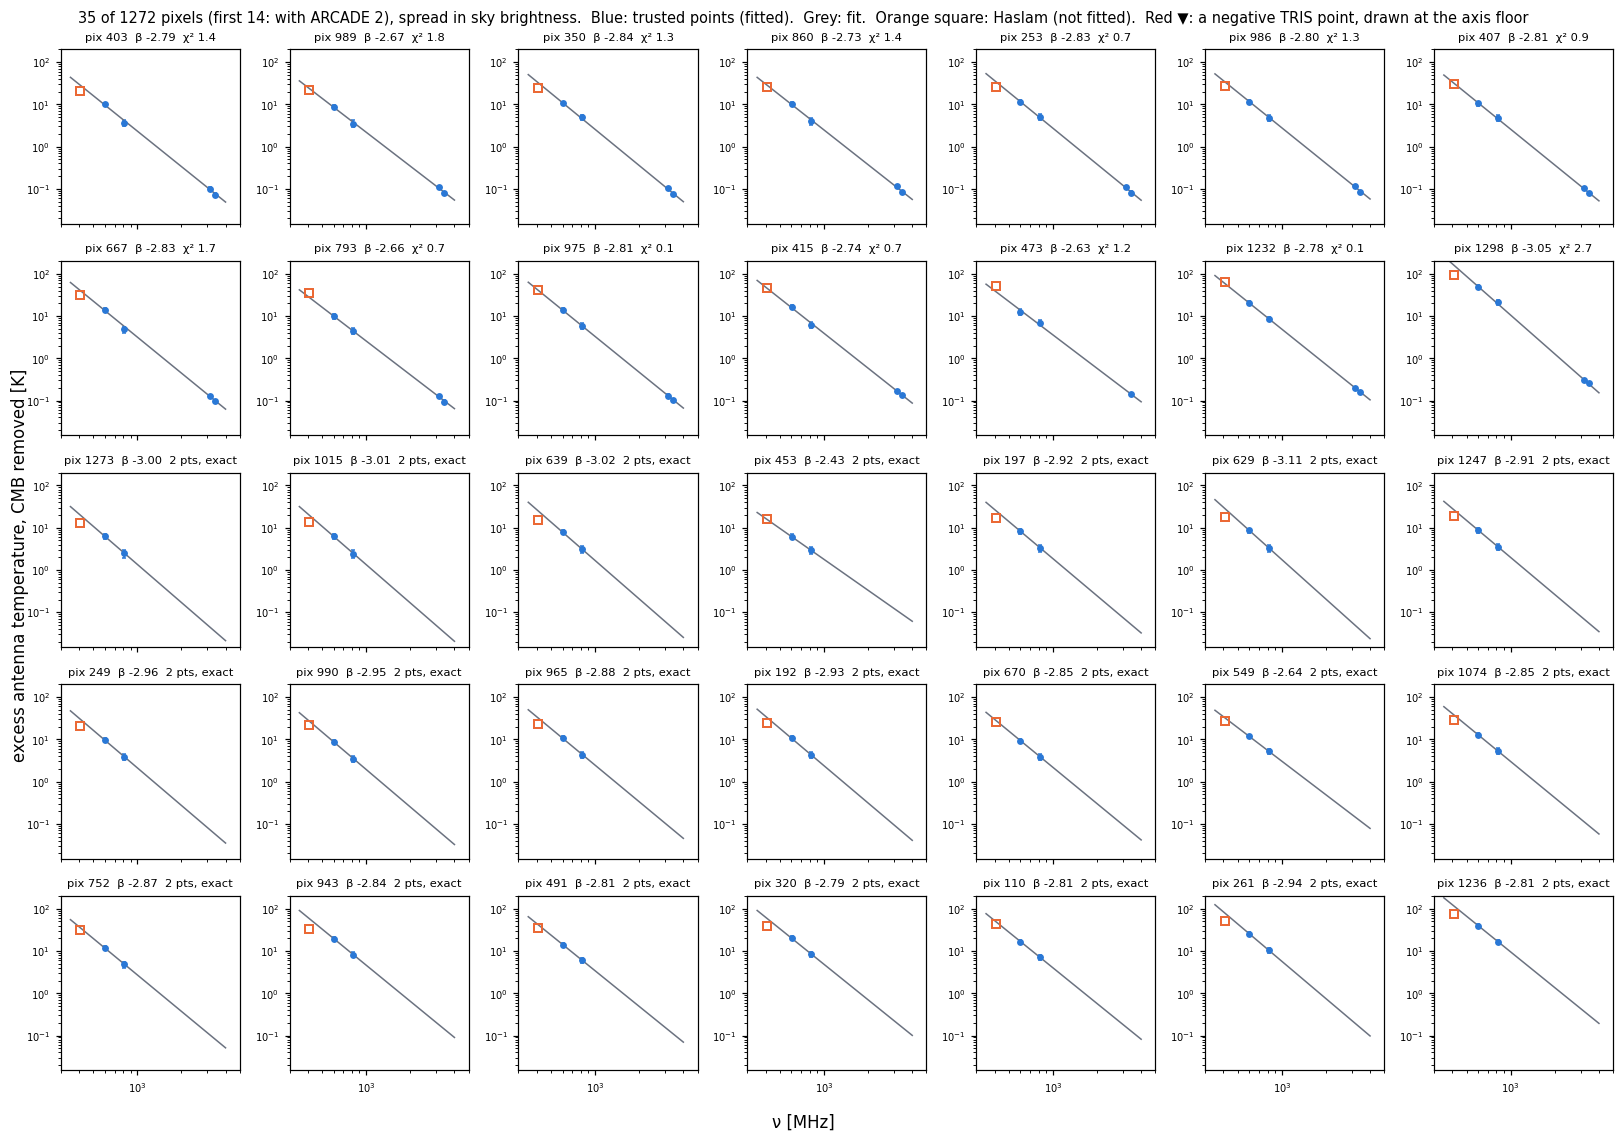

In [ ]:
fig, axes = plt.subplots(5, 7, figsize=(15, 10.5), sharex=True)
grid = np.geomspace(350, 4000, 100)
_fitted = [r for r in FIT if np.isfinite(r["beta"])]
_four = sorted([r for r in _fitted if r["n"] >= 3], key=lambda r: r["raw"])
_two = sorted([r for r in _fitted if r["n"] == 2], key=lambda r: r["raw"])
SHOWN = ([_four[i] for i in np.unique(np.linspace(0, len(_four) - 1, 14).astype(int))] +
         [_two[i] for i in np.unique(np.linspace(0, len(_two) - 1, axes.size - 14).astype(int))])
for ax, r in zip(axes.flat, SHOWN):
    ok = r["t"] > 0
    ax.errorbar(r["nu"][ok], r["t"][ok], yerr=r["s"][ok], fmt="o", ms=3.5, color="#2a78d6",
                elinewidth=1, capsize=1.5)
    if (~ok).any():
        ax.plot(r["nu"][~ok], np.full((~ok).sum(), 0.02), "v", color="#b2432a", ms=6)
    if r["positive"] and abs(r["beta"]) < 10:
        ax.plot(grid, power_law(grid, r["A"], r["beta"]), "-", color="#6b7280", lw=1)
    ax.plot(408, r["raw"] - CMB_408, "s", ms=5, mfc="none", mec="#eb6834", mew=1.3)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(0.015, 200); ax.set_xlim(300, 5000)
    chi_txt = f"χ² {r['chi2']:.1f}" if np.isfinite(r["chi2"]) else "2 pts, exact"
    ax.set_title(f"pix {r['pix']}  β {r['beta']:.2f}  {chi_txt}", fontsize=7.5,
                 color="#b2432a" if (np.isfinite(r["chi2"]) and r["chi2"] > 6) else "k")
    ax.tick_params(labelsize=6.5)
for ax in axes.flat[len(SHOWN):]:
    ax.axis("off")
fig.supxlabel("ν [MHz]"); fig.supylabel("excess antenna temperature, CMB removed [K]")
fig.suptitle(f"{len(SHOWN)} of {len(FIT)} pixels (first 14: with ARCADE 2), spread in sky brightness.  Blue: trusted points (fitted).  Grey: fit.  Orange square: Haslam (not fitted).  "
             "Red ▼: a negative TRIS point, drawn at the axis floor", fontsize=9.5)
fig.tight_layout()
plt.show()

---
### Full maps: best-fit Haslam, β and χ²

Every stripe pixel's fit on the full sky (nside 16, equatorial; grey: outside the TRIS stripe).
Best-fit and old Haslam share one colour scale. χ²/dof exists only where ARCADE 2 adds points
(3–4 points); a two-point fit is exact. The last panel shows how many points each fit used.

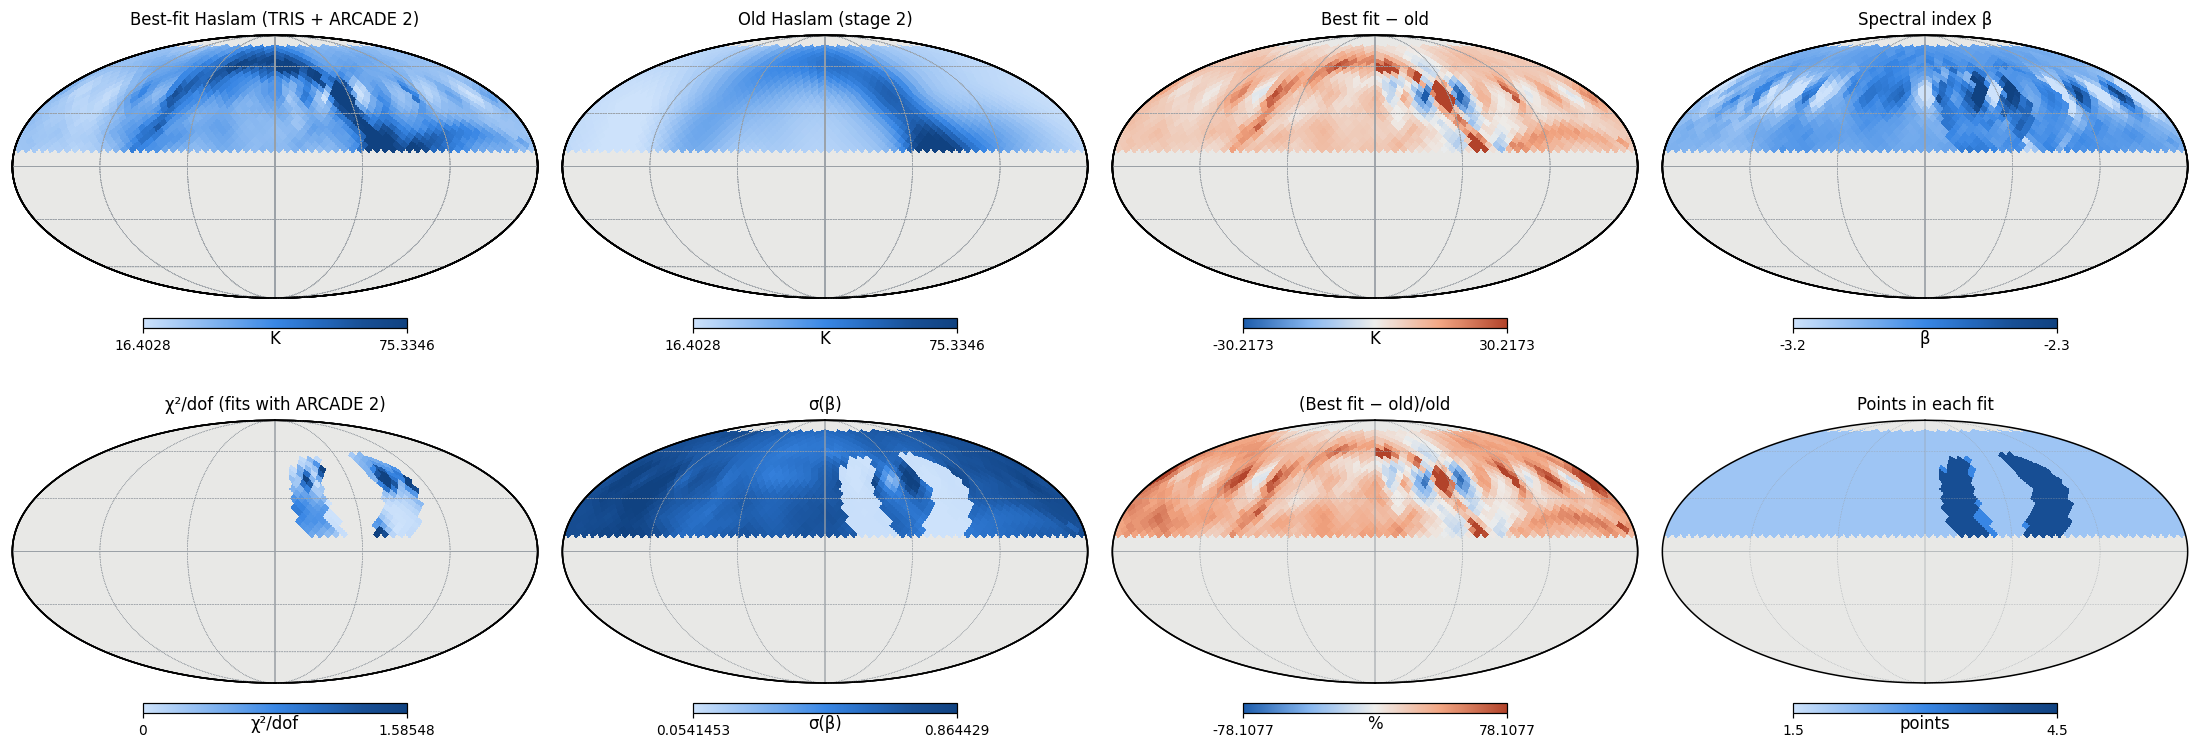

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
                                                     "#256abf", "#184f95", "#104281"])
SEQ.set_bad("#e8e8e6"); SEQ.set_under("white")
DIV = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#86b6ef", "#eeeeec", "#f2a582", "#b2432a"])
DIV.set_bad("#e8e8e6"); DIV.set_under("white")

def as_map(key):
    m = np.full(hp.nside2npix(NSIDE), np.nan)
    for r in FIT:
        m[r["pix"]] = r[key]
    return m

BEST = as_map("pred")
OLD = np.where(np.isfinite(BEST), HASLAM_MAP, np.nan)
BETA, CHI2 = as_map("beta"), as_map("chi2_dof")
SIG_BETA = as_map("sigma_beta")
N_PTS = as_map("n")
lo, hi = np.nanpercentile(np.concatenate([BEST, OLD]), [2, 98])
span = float(np.nanpercentile(np.abs(BEST - OLD), 98))
kw = dict(coord="C", notext=True, badcolor="#e8e8e6")
fig = plt.figure(figsize=(20, 7.0))
for k, (title, m, cmap, a, b, unit) in enumerate([
        ("Best-fit Haslam (TRIS + ARCADE 2)", BEST, SEQ, lo, hi, "K"),
        ("Old Haslam (stage 2)", OLD, SEQ, lo, hi, "K"),
        ("Best fit − old", BEST - OLD, DIV, -span, span, "K"),
        ("Spectral index β", BETA, SEQ, -3.2, -2.3, "β"),
        ("χ²/dof (fits with ARCADE 2)", CHI2, SEQ, 0, float(np.nanpercentile(CHI2, 95)), "χ²/dof"),
        ("σ(β)", SIG_BETA, SEQ, *np.nanpercentile(SIG_BETA, [2, 98]), "σ(β)"),
        ("(Best fit − old)/old", 100 * (BEST - OLD) / OLD, DIV,
         -float(np.nanpercentile(np.abs(100 * (BEST - OLD) / OLD), 98)),
         float(np.nanpercentile(np.abs(100 * (BEST - OLD) / OLD), 98)), "%"),
        ("Points in each fit", N_PTS, SEQ, 1.5, 4.5, "points")]):
    hp.mollview(m, sub=(2, 4, k + 1), fig=fig.number, title=title, cmap=cmap, min=a, max=b,
                unit=unit, **kw)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
plt.show()

---
## 5. The TRIS points: pixel-scale and prior-dominated

At nside 16, with the stage 1 and stage 2 products, **every stripe pixel can be fitted**:
there are no negative TRIS points, and no χ²/dof above 3 where ARCADE 2 is present. (On the
old nside 8 grid, two pixels had negative TRIS values.) Where TRIS is alone, though, β
comes from 600 and 820 MHz only, a lever arm of 1.36 in frequency. With ~10% TRIS errors,
σ(β) is 0.5–0.9 there, against ~0.05 with ARCADE 2, and 18 TRIS-only pixels fall outside the
synchrotron range. Two properties of the TRIS points matter everywhere:

* **They are pixel values of a deconvolved map**: 3.7° pixels solved from one 19–23°-beam
  ring against a prior, not the sky seen through the TRIS beam. Haslam and ARCADE 2 *are*
  at the TRIS beam.
* **They are mostly the GSM2008 prior** (the data narrowed only 23 of 1272 pixels by more
  than 5%), and GSM2008 is built partly from Haslam. So the TRIS half of each SED is
  partly circular. ARCADE 2 is the independent half.

---
## 6. Sensitivity: the two upstream choices that move the answer

Two choices that are not stage 3's to make, each switched on and off:

* **ẑ added back or not** (see the conventions above);
* **TRIS left as the stage 1 pixel map, or smoothed to the same 23.366° target** with
  `smooth_to_target(native = 0)`, mask-aware on the band. Only the values change; the TRIS
  σ are left as they are, which overstates them after smoothing.

This is a diagnostic, not a pipeline change.

In [ ]:
def tris_smoothed(with_z):
    out = {}
    for row, (nu, tr) in enumerate(TRIS_MAP.items()):
        m = np.where(band, tr["with_z" if with_z else "sky_only"], hp.UNSEEN)
        out[nu] = smooth_to_target(m, 0.0, TARGET_FWHM_DEG, weight_mask=band)
    return out

CASES = {"stage 1 pixels + ẑ  (primary)": FIT,
         "stage 1 pixels, no ẑ": fit_all(with_z=False),
         "TRIS smoothed + ẑ": fit_all(tris_maps=tris_smoothed(True), with_z=True),
         "TRIS smoothed, no ẑ": fit_all(tris_maps=tris_smoothed(False), with_z=False)}
print(f"{'case':<32}{'neg. SEDs':>10}{'β median':>10}{'β out':>7}{'χ²/dof ≤1 / 1–3 / >3':>24}"
      f"{'median pred−raw':>18}")
for name, rows in CASES.items():
    s = summarise(rows, name)
    print(f"{name:<32}{s['negative']:10d}{s['beta_med']:10.3f}{s['beta_out']:7d}"
          f"{s['chi_le1']:>12d} / {s['chi_1_3']:2d} / {s['chi_3_10'] + s['chi_gt10']:2d}"
          f"{s['diff_med']:+11.2f} K ({100 * s['frac_med']:+.0f}%)")

case                             neg. SEDs  β median  β out    χ²/dof ≤1 / 1–3 / >3   median pred−raw
stage 1 pixels + ẑ  (primary)            0    -2.873     18         149 / 18 /  0      +7.28 K (+29%)
stage 1 pixels, no ẑ                     0    -2.704     22         146 / 21 /  0      +0.29 K (+1%)
TRIS smoothed + ẑ                        0    -2.889      0         167 /  0 /  0      +8.39 K (+32%)
TRIS smoothed, no ẑ                      0    -2.721      0         167 /  0 /  0      +1.39 K (+5%)


---
## Verdict: stop here, before stage 4

**Every one of the 1272 TRIS-stripe pixels is fitted:** 153 with four points, 14 with
three (one ARCADE 2 band), and 1105 with the two TRIS bands only.

* **Where ARCADE 2 is present (167 pixels), the fit is clean and well constrained.**
  Median β is **−2.79**, all inside the synchrotron range, with σ(β) ≈ 0.05. χ²/dof ≤ 1 for
  149 pixels and 1–3 for the rest. Best-fit Haslam is above old Haslam: median
  **+3.4 K (+9.6%)**.
* **Where TRIS is alone (1105 pixels), the fit is exact but poorly constrained.** β comes
  from 600 and 820 MHz only, so σ(β) is 0.5–0.9. The median is −2.89, with 18 pixels outside
  the range. The extrapolation to 408 MHz gives median **+7.7 K (+31%)**.
* **The TRIS-only number is driven by ẑ.** Adding the fitted zero level raises 600 MHz by
  1.74 K but 820 MHz by only 0.52 K, so it steepens the two-point slope, and extrapolating
  that slope to 408 MHz amplifies the difference. Without ẑ, the whole stripe gives **+1%**;
  with it, **+29%**. Smoothing TRIS moves that to +5% / +32% (section 6). Until ẑ is decided
  (`TODO.md` N-3), the TRIS-only correction is undetermined: anywhere from +1% to +32%.
* **Circularity.** The TRIS points are mostly the GSM2008 prior, which is built partly from
  Haslam. ARCADE 2 is the independent part of the fit, and it covers 167 of 1272 pixels.

**Read the ARCADE 2 pixels as the measurement** (~+10%, the same sign as the TOD route in
`notebooks/07`), and the TRIS-only pixels as an extrapolation whose size depends on ẑ.
